In [1]:
import sys
sys.path.append("../../")

import torch
import torchvision.utils
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.autograd import Variable
from torch import optim
from torch.utils.data import DataLoader
from torchvision import models
from torchsummary import summary

import numpy as np
import cv2
import pandas as pd
from sklearn.metrics import accuracy_score

import src.dataPreparation.CreatePartial as create_partial
import src.neuralNetworksArch.BstCnn as bst
import src.utils.Visual as vis
import src.utils.Checkpoint as ckp
import src.utils.Metrics as metrics

from src.config.Param import *

In [2]:
PROB_SAME = {
    'partial_1' : [
        0.328,
        0.368,
        0.304,
    ],
    'partial_2' : [
        0.352697095,
        0.369294606,
        0.278008299
    ],
    'partial_3' : [
        0.26993865,
        0.251533742,
        0.260736196,
        0.217791411
    ]
}

PROB_DIFF = {
    'partial_1' : [
        0.336099585,
        0.356846473,
        0.307053942
    ],
    'partial_2' : [
        0.330396476,
        0.374449339,
        0.295154185
    ],
    'partial_3' : [
        0.266666667,
        0.25,
        0.26,
        0.223333333
    ]
}

In [7]:
MODEL_PATH = [
    '../../models/PARTIAL_1 #1.pth',
    '../../models/PARTIAL_1 #2.pth',
    '../../models/PARTIAL_1 #3.pth',
#     '../../models/PARTIAL_3 #4.pth'
]

PATH = '../../dataset/testing/diff_cam/'
DATATEST_PATH = PATH + 'testing.csv'
IMAGES_PATH = PATH + '/images/full/'
IMAGES_OCCL_PATH = PATH + '/images/occl_20/'

In [8]:
def cv_image2tensor(img, transform, convert=True):
    if convert:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = transform(img)
    img = [img]
    img_tensors = torch.stack(img)

    return img_tensors

In [9]:
models = []
for index, path in enumerate(MODEL_PATH):
    data = {}
    model  = bst.BstCnn()
    checkpoint = ckp.load_checkpoint(load_dir=path)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    
    data['id'] = 'PART-' + str(index+1)
    data['model'] = model
    data['max_dist'] = checkpoint['max_dist']
    data['threshold'] = checkpoint['threshold']
    models.append(data)

No-1
--------------------------------------------------
PART-1 DISTANCE => 0.17512379569667785
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.04112837209043997
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.12743696056171244
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1126655706749557
Concatenate thresh => 0.12452072504805184
Image label => 0
No-2
--------------------------------------------------
PART-1 DISTANCE => 0.16717065549039326
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.15224424444315535
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.17345850631493204
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.16377492773602076
Conc

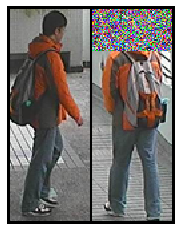


No-5
--------------------------------------------------
PART-1 DISTANCE => 0.19783966164625674
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.14444309364034574
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1543398826156148
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1654285060555552
Concatenate thresh => 0.12452072504805184
Image label => 1
No-6
--------------------------------------------------
PART-1 DISTANCE => 0.1933891392346121
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1637298248493922
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2580580700072837
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20266216762332212
Concate

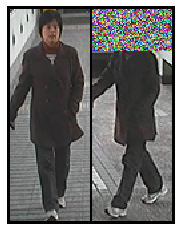


No-8
--------------------------------------------------
PART-1 DISTANCE => 0.23244820933545984
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.15161040190467492
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.16395473839083335
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.18257033261392103
Concatenate thresh => 0.12452072504805184
Image label => 1
No-9
--------------------------------------------------
PART-1 DISTANCE => 0.21554558982754343
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.10561152135785845
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1759302887949621
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.16415197088602507
Con

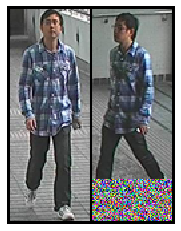


No-11
--------------------------------------------------
PART-1 DISTANCE => 0.20763086449176418
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.18501452388681058
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1664837762339056
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.18692592746332243
Concatenate thresh => 0.12452072504805184
Image label => 1
No-12
--------------------------------------------------
PART-1 DISTANCE => 0.22265214965714586
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.20192719975019038
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3861646304839222
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2654636761838082
Con

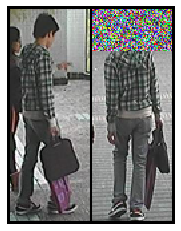


No-14
--------------------------------------------------
PART-1 DISTANCE => 0.24803883385838119
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.17573521970040126
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.16073637048140635
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1954309786347424
Concatenate thresh => 0.12452072504805184
Image label => 1
No-15
--------------------------------------------------
PART-1 DISTANCE => 0.2535564253832921
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.10465460179186564
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.18146293831567012
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.178284745414784
Conc

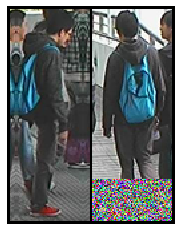


No-17
--------------------------------------------------
PART-1 DISTANCE => 0.21900275608052522
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.24526292030406668
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.4636834133158082
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.30350376339934126
Concatenate thresh => 0.12452072504805184
Image label => 1
No-18
--------------------------------------------------
PART-1 DISTANCE => 0.19978323610999357
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1890324443945264
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2373538772732849
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20748306747702755
Con

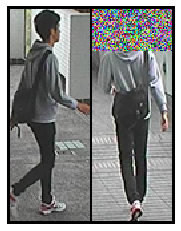


No-20
--------------------------------------------------
PART-1 DISTANCE => 0.1611594644297803
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.17382988137745814
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2571920826412708
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.19516805201141774
Concatenate thresh => 0.12452072504805184
Image label => 1
No-21
--------------------------------------------------
PART-1 DISTANCE => 0.3632543426204135
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1580704767981911
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.09424649919628562
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20743528503295094
Conc

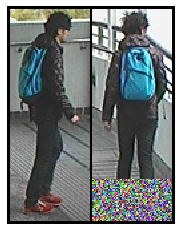


No-26
--------------------------------------------------
PART-1 DISTANCE => 0.2742069136211903
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.11393146064572825
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1455759029913671
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1775165246410882
Concatenate thresh => 0.12452072504805184
Image label => 1
No-27
--------------------------------------------------
PART-1 DISTANCE => 0.16435659891372154
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.3906021164700321
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.06677384835621486
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.21512834565586542
Conc

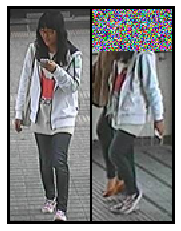


No-35
--------------------------------------------------
PART-1 DISTANCE => 0.11657410257202569
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2168090770744134
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2602640351292769
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1964631599118658
Concatenate thresh => 0.12452072504805184
Image label => 1
No-36
--------------------------------------------------
PART-1 DISTANCE => 0.04678995762241284
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.07300874333666166
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3071914953070439
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.13610335747981284
Conc

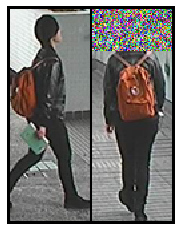


No-38
--------------------------------------------------
PART-1 DISTANCE => 0.26940560932830077
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.37069322169246016
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.4001044443619843
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.3456813290709425
Concatenate thresh => 0.12452072504805184
Image label => 1
No-39
--------------------------------------------------
PART-1 DISTANCE => 0.16547542962701667
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.18719809014128314
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.061301721488287816
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.14124013667895485
C

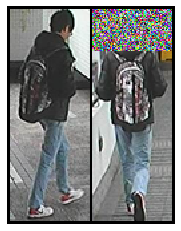


No-53
--------------------------------------------------
PART-1 DISTANCE => 0.22671500502816044
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.11158970374603347
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2552378349662392
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.19439099468205376
Concatenate thresh => 0.12452072504805184
Image label => 1
No-54
--------------------------------------------------
PART-1 DISTANCE => 0.30769492879347704
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.19136664930506272
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.32830384643240357
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.27251164194926386
C

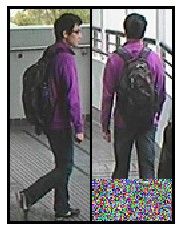


No-56
--------------------------------------------------
PART-1 DISTANCE => 0.113896907337137
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2498067493029645
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.12091452645575067
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.16455064270245484
Concatenate thresh => 0.12452072504805184
Image label => 1
No-57
--------------------------------------------------
PART-1 DISTANCE => 0.3059726461646624
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.12923866383944055
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.19724898482585074
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20952171910990752
Conc

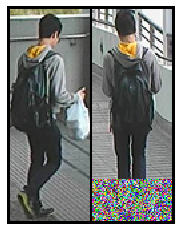


No-59
--------------------------------------------------
PART-1 DISTANCE => 0.3434825969354991
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.19815316452259085
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.13048475844343516
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.22622047560939332
Concatenate thresh => 0.12452072504805184
Image label => 1
No-60
--------------------------------------------------
PART-1 DISTANCE => 0.26239846160012065
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.17114013899979882
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2530978768762314
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.22697746984592443
Co

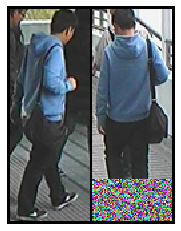


No-62
--------------------------------------------------
PART-1 DISTANCE => 0.2042166639998703
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.14316024287320558
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.08966620628998394
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1472557258690924
Concatenate thresh => 0.12452072504805184
Image label => 1
No-63
--------------------------------------------------
PART-1 DISTANCE => 0.15847243124025
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.03505728635044686
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.09471452872729497
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.09485505677128524
Conca

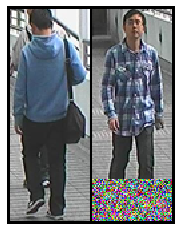


No-64
--------------------------------------------------
PART-1 DISTANCE => 0.17400877013979418
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.21522356047824226
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.23080611194777068
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20615597040476444
Concatenate thresh => 0.12452072504805184
Image label => 0


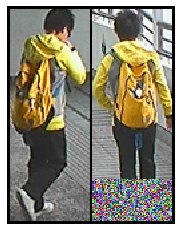


No-65
--------------------------------------------------
PART-1 DISTANCE => 0.11889429191354929
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.3367150096825912
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2144799902230244
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.22597281226050742
Concatenate thresh => 0.12452072504805184
Image label => 1
No-66
--------------------------------------------------
PART-1 DISTANCE => 0.27968192181279333
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.13357855056114595
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.39882191645057824
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2641278540916241
Con

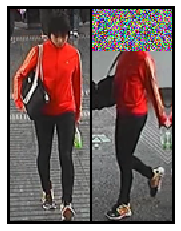


No-68
--------------------------------------------------
PART-1 DISTANCE => 0.10968216121258365
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.17318019431831225
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3318416599823364
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20055616021879685
Concatenate thresh => 0.12452072504805184
Image label => 1
No-69
--------------------------------------------------
PART-1 DISTANCE => 0.18486415476882853
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.03819401546129
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1949993002554476
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.13563746923692463
Conca

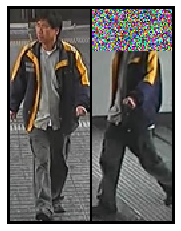


No-71
--------------------------------------------------
PART-1 DISTANCE => 0.19173395355980605
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.4219494900748812
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.32217536384188467
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.3139381050221649
Concatenate thresh => 0.12452072504805184
Image label => 1
No-72
--------------------------------------------------
PART-1 DISTANCE => 0.14418139192086132
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.09301789674864881
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.17481410093793776
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.13532977318013703
Co

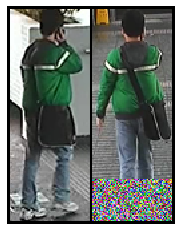


No-74
--------------------------------------------------
PART-1 DISTANCE => 0.2443626320943795
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.14064468222710705
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.13627169256732816
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.17416149842118778
Concatenate thresh => 0.12452072504805184
Image label => 1
No-75
--------------------------------------------------
PART-1 DISTANCE => 0.28024866066142873
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.145400414333444
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1964678692004343
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2064033172870739
Conca

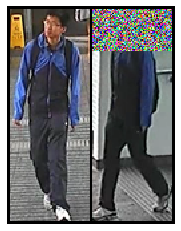


No-77
--------------------------------------------------
PART-1 DISTANCE => 0.29976253529425984
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.11684542536135381
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.19302457367508874
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20171489788713787
Concatenate thresh => 0.12452072504805184
Image label => 1
No-78
--------------------------------------------------
PART-1 DISTANCE => 0.20192848386353632
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.33750513751254296
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.331012507418498
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2899442928210988
Con

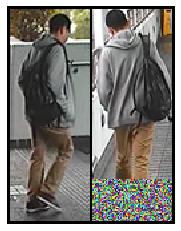


No-80
--------------------------------------------------
PART-1 DISTANCE => 0.15445597391964916
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1265208271364338
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.18707131894496726
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1545020855770355
Concatenate thresh => 0.12452072504805184
Image label => 1
No-81
--------------------------------------------------
PART-1 DISTANCE => 0.060613364252364396
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.36375557412396925
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3559932323538543
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2594861455504749
Con

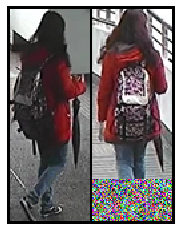


No-83
--------------------------------------------------
PART-1 DISTANCE => 0.2689913826783467
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1898105075553833
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.22193602319962416
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.22628743304149496
Concatenate thresh => 0.12452072504805184
Image label => 1
No-84
--------------------------------------------------
PART-1 DISTANCE => 0.12264441696743336
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.06146401596732727
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2884952271509288
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.15173755170455586
Con

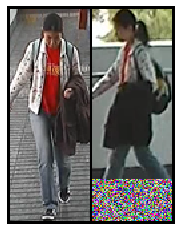


No-86
--------------------------------------------------
PART-1 DISTANCE => 0.15017040217023175
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.19774751702321725
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2373634652128161
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1939211015233156
Concatenate thresh => 0.12452072504805184
Image label => 1
No-87
--------------------------------------------------
PART-1 DISTANCE => 0.2738476227218395
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.19745636045651968
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.15438065566881382
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20990486704202646
Con

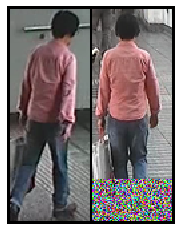


No-89
--------------------------------------------------
PART-1 DISTANCE => 0.1681469362486772
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.15859137120055491
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.23274775721952398
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.18457300329926746
Concatenate thresh => 0.12452072504805184
Image label => 1
No-90
--------------------------------------------------
PART-1 DISTANCE => 0.20728478647221388
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.14362345211221192
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3726207032125471
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.23533450882867657
Co

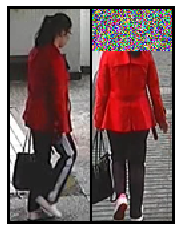


No-92
--------------------------------------------------
PART-1 DISTANCE => 0.3753447968864872
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.35770330664500993
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.13093330092493083
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2940019800102391
Concatenate thresh => 0.12452072504805184
Image label => 1
No-93
--------------------------------------------------
PART-1 DISTANCE => 0.17771902709760873
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2784031315067445
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3388731786707281
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.26313081215336437
Conc

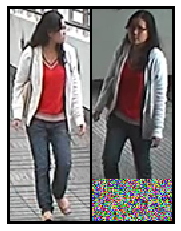


No-95
--------------------------------------------------
PART-1 DISTANCE => 0.29882509007703933
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.08259652198114827
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1979313427292807
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.19068486534389895
Concatenate thresh => 0.12452072504805184
Image label => 1
No-96
--------------------------------------------------
PART-1 DISTANCE => 0.22542549679663193
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.15655103817866078
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.24508640464403228
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2068848484168675
Co

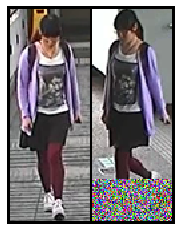


No-98
--------------------------------------------------
PART-1 DISTANCE => 0.13444362379692046
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.20391888839656536
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2196430859364881
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1853964576362795
Concatenate thresh => 0.12452072504805184
Image label => 1
No-99
--------------------------------------------------
PART-1 DISTANCE => 0.15323158357836755
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.08370283053799167
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.0935899878884681
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.11010730622006756
Con

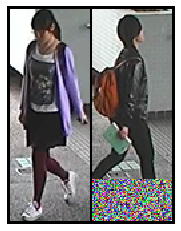


No-100
--------------------------------------------------
PART-1 DISTANCE => 0.40216648396816856
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1866579262098919
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.324067746941564
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.30128249016157044
Concatenate thresh => 0.12452072504805184
Image label => 0


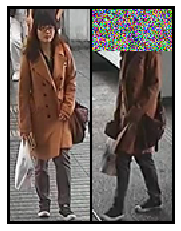


No-101
--------------------------------------------------
PART-1 DISTANCE => 0.28963429884620007
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2692936583655984
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.5549727333002403
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.363849025295358
Concatenate thresh => 0.12452072504805184
Image label => 1
No-102
--------------------------------------------------
PART-1 DISTANCE => 0.10895330166729333
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.12794105622320934
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.15181594991275948
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1288901600190914
Con

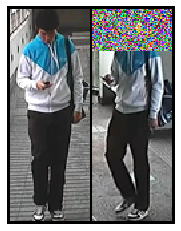


No-107
--------------------------------------------------
PART-1 DISTANCE => 0.2669238633710978
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.23837561418731032
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.29927763335579205
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.26667087395189976
Concatenate thresh => 0.12452072504805184
Image label => 1
No-108
--------------------------------------------------
PART-1 DISTANCE => 0.2414042090307414
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.12019852397567565
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.09583745536940562
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.15345554227543629


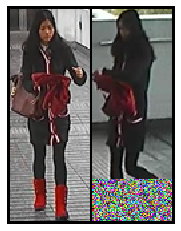


No-113
--------------------------------------------------
PART-1 DISTANCE => 0.2960122572692637
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.22453984549818135
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2257362312326294
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.24892904838930607
Concatenate thresh => 0.12452072504805184
Image label => 1
No-114
--------------------------------------------------
PART-1 DISTANCE => 0.17590626205603577
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2423893074324533
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.16506357484594533
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.19630121246317805
C

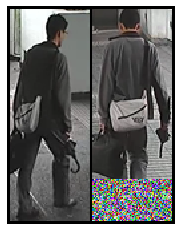


No-116
--------------------------------------------------
PART-1 DISTANCE => 0.186241219840598
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.24788913031940826
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2283587174518625
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.22117240293149554
Concatenate thresh => 0.12452072504805184
Image label => 1
No-117
--------------------------------------------------
PART-1 DISTANCE => 0.2974457878027566
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.24390569131479592
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2194996169102781
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.254406514170607
Conca

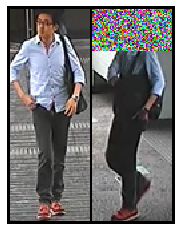


No-119
--------------------------------------------------
PART-1 DISTANCE => 0.1675661431791252
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2701973051663937
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.19044967708675378
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.21121619064740166
Concatenate thresh => 0.12452072504805184
Image label => 1
No-120
--------------------------------------------------
PART-1 DISTANCE => 0.2827990141623715
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1246871748556251
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.20686907215428205
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20306277395680103
Co

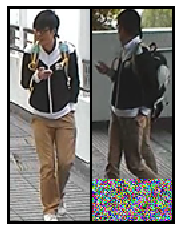


No-122
--------------------------------------------------
PART-1 DISTANCE => 0.37435446190728666
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.08583809183218817
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.40631614560007706
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2812123738140534
Concatenate thresh => 0.12452072504805184
Image label => 1
No-123
--------------------------------------------------
PART-1 DISTANCE => 0.12111511695712311
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.17431118762010672
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.294912650953648
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.19346316507417957
C

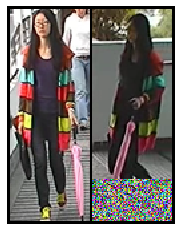


No-125
--------------------------------------------------
PART-1 DISTANCE => 0.13637806779740874
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.17426206497765415
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.16686103150982004
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1592567527460601
Concatenate thresh => 0.12452072504805184
Image label => 1
No-126
--------------------------------------------------
PART-1 DISTANCE => 0.23729964991031305
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.15029149598194064
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.15420101307763834
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1807353330444331


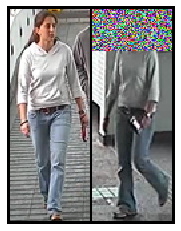


No-128
--------------------------------------------------
PART-1 DISTANCE => 0.1699036756204738
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.19008446194044312
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3859632254093078
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.24344705451052823
Concatenate thresh => 0.12452072504805184
Image label => 1
No-129
--------------------------------------------------
PART-1 DISTANCE => 0.10207633235544
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.05074923600714377
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.24756627755579655
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.12843370024935277
Con

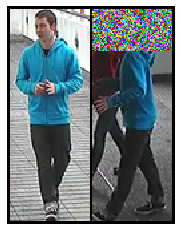


No-131
--------------------------------------------------
PART-1 DISTANCE => 0.3371125356460934
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.273613149316788
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2627301970930301
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.29161361332891966
Concatenate thresh => 0.12452072504805184
Image label => 1
No-132
--------------------------------------------------
PART-1 DISTANCE => 0.11960775874069285
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.33413054774214807
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.4039067527955359
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.28345458620515945
Con

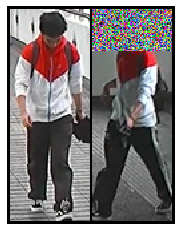


No-134
--------------------------------------------------
PART-1 DISTANCE => 0.06489338123827668
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.12143877812980967
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2560390210857655
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1437634288946891
Concatenate thresh => 0.12452072504805184
Image label => 1
No-135
--------------------------------------------------
PART-1 DISTANCE => 0.21389308114719768
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.3926592814023897
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2730298223426763
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2958433387009802
Con

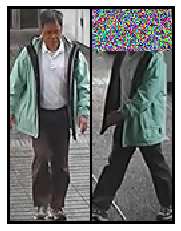


No-137
--------------------------------------------------
PART-1 DISTANCE => 0.15641472120555922
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.059829280303918576
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.18291128118132127
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.13008442046665597
Concatenate thresh => 0.12452072504805184
Image label => 1
No-138
--------------------------------------------------
PART-1 DISTANCE => 0.14063194584455505
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.04077813027250724
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.31224352261754096
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.157693475083058

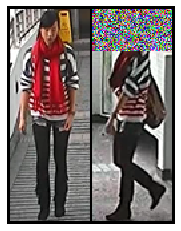


No-140
--------------------------------------------------
PART-1 DISTANCE => 0.16880125105894253
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.24013071498129512
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.11197669978998329
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.17680671621109978
Concatenate thresh => 0.12452072504805184
Image label => 1
No-141
--------------------------------------------------
PART-1 DISTANCE => 0.40242974725195046
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2732071161182745
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.29155712494372676
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.32227323136050096

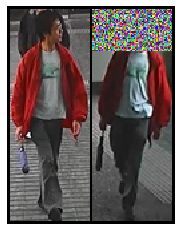


No-143
--------------------------------------------------
PART-1 DISTANCE => 0.21405113854868962
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.28344545350196304
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3524989826671057
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2813252113839776
Concatenate thresh => 0.12452072504805184
Image label => 1
No-144
--------------------------------------------------
PART-1 DISTANCE => 0.22532771001327484
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.23498730895550204
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1343774424449409
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20084806564359145
C

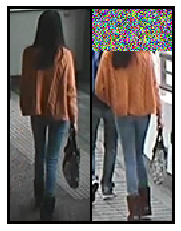


No-149
--------------------------------------------------
PART-1 DISTANCE => 0.21533634446769265
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.11620165492701338
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3001821280651554
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20601271246883113
Concatenate thresh => 0.12452072504805184
Image label => 1
No-150
--------------------------------------------------
PART-1 DISTANCE => 0.33388484518252665
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2157040953226111
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.12808562453971084
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.22852099945961618


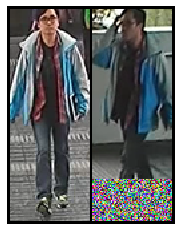


No-152
--------------------------------------------------
PART-1 DISTANCE => 0.22948125813232675
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.18243853189947878
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.20403191721994718
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.20487990674738235
Concatenate thresh => 0.12452072504805184
Image label => 1
No-153
--------------------------------------------------
PART-1 DISTANCE => 0.2653475151831477
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.11130952417685633
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.22288610438010528
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.19734165781459134

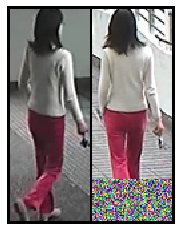


No-155
--------------------------------------------------
PART-1 DISTANCE => 0.18704567579730838
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.23936272628197136
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.44995099454354837
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2864409452343228
Concatenate thresh => 0.12452072504805184
Image label => 1
No-156
--------------------------------------------------
PART-1 DISTANCE => 0.31674982431267784
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.23005480321938443
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.5163380434426623
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.34709736126949703


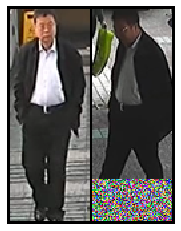


No-158
--------------------------------------------------
PART-1 DISTANCE => 0.24653260380390205
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.25623573684580797
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.16210019167321876
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.22406982762966102
Concatenate thresh => 0.12452072504805184
Image label => 1
No-159
--------------------------------------------------
PART-1 DISTANCE => 0.18663628685877187
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1545276759189205
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.1052565946548229
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.1501904870019875
C

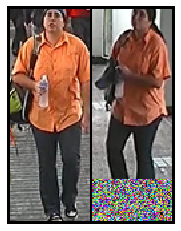


No-161
--------------------------------------------------
PART-1 DISTANCE => 0.34420446761310913
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.3563706389769654
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2677169175050571
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.3250601191796149
Concatenate thresh => 0.12452072504805184
Image label => 1
No-162
--------------------------------------------------
PART-1 DISTANCE => 0.18530601182589074
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.43198266637209537
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.3191906557691663
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.31444151366819245
Co

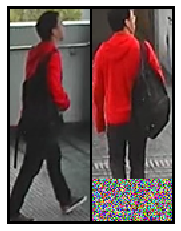


No-164
--------------------------------------------------
PART-1 DISTANCE => 0.1670646273883762
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.1746963004972742
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2552923092433727
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.19687862052747396
Concatenate thresh => 0.12452072504805184
Image label => 1
No-165
--------------------------------------------------
PART-1 DISTANCE => 0.28039318011950715
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.4134279767025377
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.20236682468680112
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.30390787805092856
Co

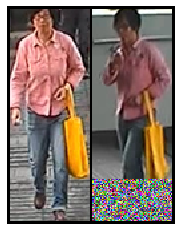


No-167
--------------------------------------------------
PART-1 DISTANCE => 0.3536957514721175
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.3336733245537924
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.2254611176573595
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.30717586923166496
Concatenate thresh => 0.12452072504805184
Image label => 1
No-168
--------------------------------------------------
PART-1 DISTANCE => 0.367527437663507
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.19188427297872052
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.214300444872615
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2578008416819338
Concat

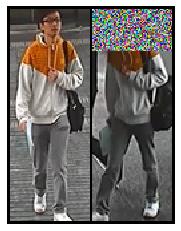


No-170
--------------------------------------------------
PART-1 DISTANCE => 0.18642855208865228
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.47697391563001024
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.27875938441460785
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.31845918634871434
Concatenate thresh => 0.12452072504805184
Image label => 1
No-171
--------------------------------------------------
PART-1 DISTANCE => 0.3183416799471087
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.4056020177310523
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.4501623181762984
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.38995627032332625
C

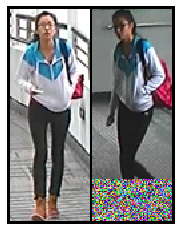


No-176
--------------------------------------------------
PART-1 DISTANCE => 0.14067766508565924
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.0976354251391911
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.10002014050746144
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.11283414037704485
Concatenate thresh => 0.12452072504805184
Image label => 1


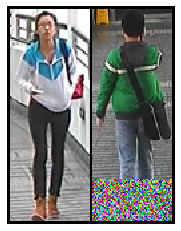


No-177
--------------------------------------------------
PART-1 DISTANCE => 0.30551105583414995
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.28714930691407364
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.38660563680605003
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.32385914125616927
Concatenate thresh => 0.12452072504805184
Image label => 1
No-178
--------------------------------------------------
PART-1 DISTANCE => 0.0750426320928498
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.06763195847532204
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.17946333754735916
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.10446094858610887

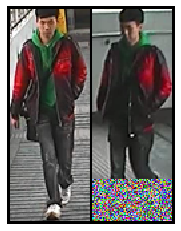


No-191
--------------------------------------------------
PART-1 DISTANCE => 0.09228227086227674
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.17321461410955336
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.06850533202237222
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.11386188930220717
Concatenate thresh => 0.12452072504805184
Image label => 1


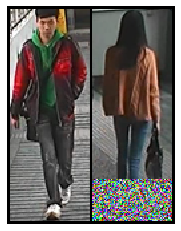


No-192
--------------------------------------------------
PART-1 DISTANCE => 0.27523522367894915
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.2890224779287524
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.22528365325934321
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.2648173301239151
Concatenate thresh => 0.12452072504805184
Image label => 1
No-193
--------------------------------------------------
PART-1 DISTANCE => 0.1953897336803534
Threshold => 0.14810317754745483
--------------------------------------------------
PART-2 DISTANCE => 0.05360142329153795
Threshold => 0.10267487168312073
--------------------------------------------------
PART-3 DISTANCE => 0.12309546180456613
Threshold => 0.12409592419862747
--------------------------------------------------
Concatenate distance => 0.12259483404199512
C

In [10]:
trans = transforms.Compose([transforms.ToTensor()])
df = pd.read_csv(DATATEST_PATH)
y_true = []
y_pred = []

verbose = True
with torch.no_grad():
    for index, data in df.iterrows():
        if verbose == True:
            print('No-{}'.format(index+1))
            print('-'*50)
        img1 = cv2.imread(IMAGES_PATH + data['image_1'])
        img2 = cv2.imread(IMAGES_OCCL_PATH + data['image_2'])
        label = data['label']

        img1_part = list(create_partial.partial_image_1(img1))
        img2_part = list(create_partial.partial_image_1(img2))

        thresholds = []
        dists = []
        for i, (input1, input2, model) in enumerate(zip(img1_part, img2_part, models)):
            input1 = cv_image2tensor(img1, trans)
            input2 = cv_image2tensor(img2, trans)
            out1, out2 = model['model'](input1, input2)
            euclidean_distance = F.pairwise_distance(out1, out2)
            
            dist = metrics.normalize_dist(euclidean_distance.item(), model['max_dist'])
            dists.append(dist)
            thresholds.append(model['threshold'])
            
            if verbose == True:
                print('PART-{} DISTANCE => {}'.format((i+1), dist))
                print('Threshold => {}'.format(model['threshold']))
                print('-'*50)
            
        cat_dist, cat_thresh = metrics.concatenate(dists, thresholds, PROB_DIFF['partial_1'])
        
        if verbose == True:
            print('Concatenate distance => {}'.format(cat_dist))
            print('Concatenate thresh => {}'.format(cat_thresh))
            print('Image label => {}'.format(label))
        
        y_true.append(float(label))
        pred = 0.0 if cat_dist <= cat_thresh else 1.0
        y_pred.append(pred)
        concatenated = torch.cat((cv_image2tensor(img1, trans, True), cv_image2tensor(img2, trans, True)),0)
        
        if verbose == True and pred != float(label):
            vis.imshow(torchvision.utils.make_grid(concatenated))
            print('='*50, end='\n\n')

acc = accuracy_score(np.array(y_true), np.array(y_pred))
print('Accuracy : {}'.format(acc))